<a href="https://colab.research.google.com/github/skarthik1215/ml-project/blob/main/Edge_Detection_Sobel_vs_Canny.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Edge Detection: Comparative Study of Sobel vs. Canny for Medical X-Ray Boundary Detection

**Submitted by:** SANAPATHI KARTHIK

**Enrollment ID:** 23STUCHH010481

**Program:** B.Tech CSE AI-ML (Class of 2027)

## SECTION 1: Setup and Libraries

In [1]:
# Install required libraries
!pip install opencv-python numpy matplotlib pillow seaborn scikit-learn scipy -q

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns
from scipy import ndimage
from sklearn.metrics import mean_squared_error
import time
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 10

print("="*80)
print("EDGE DETECTION: SOBEL vs. CANNY COMPARATIVE ANALYSIS")
print("="*80)
print("\n✓ All libraries imported successfully!")
print(f"✓ OpenCV version: {cv2.__version__}")
print(f"✓ NumPy version: {np.__version__}")

EDGE DETECTION: SOBEL vs. CANNY COMPARATIVE ANALYSIS

✓ All libraries imported successfully!
✓ OpenCV version: 5.0.0
✓ NumPy version: 2.1.3


## SECTION 2: Case Design and Methodology

### Problem Definition
Medical X-ray images contain crucial boundary information for diagnosis. Edge detection helps identify anatomical structures and abnormalities.

### Methodology
- Load/create medical X-ray images
- Apply preprocessing (grayscale, noise reduction)
- Apply Sobel and Canny edge detection
- Compare results based on edge clarity, noise sensitivity, and computational efficiency

### Algorithm Descriptions

**SOBEL:** First-order derivative-based, uses 3x3 kernels, fast but sensitive to noise

**CANNY:** Multi-stage algorithm with Gaussian blur, gradient, non-max suppression, and hysteresis thresholding. Optimal edge detection.

## SECTION 3: Data Acquisition and Preprocessing


SECTION 3: DATA ACQUISITION AND PREPROCESSING

Generating synthetic X-ray images...
✓ Synthetic X-ray images generated successfully
  Image dimensions: (512, 512)
  Pixel value range: [0, 159]


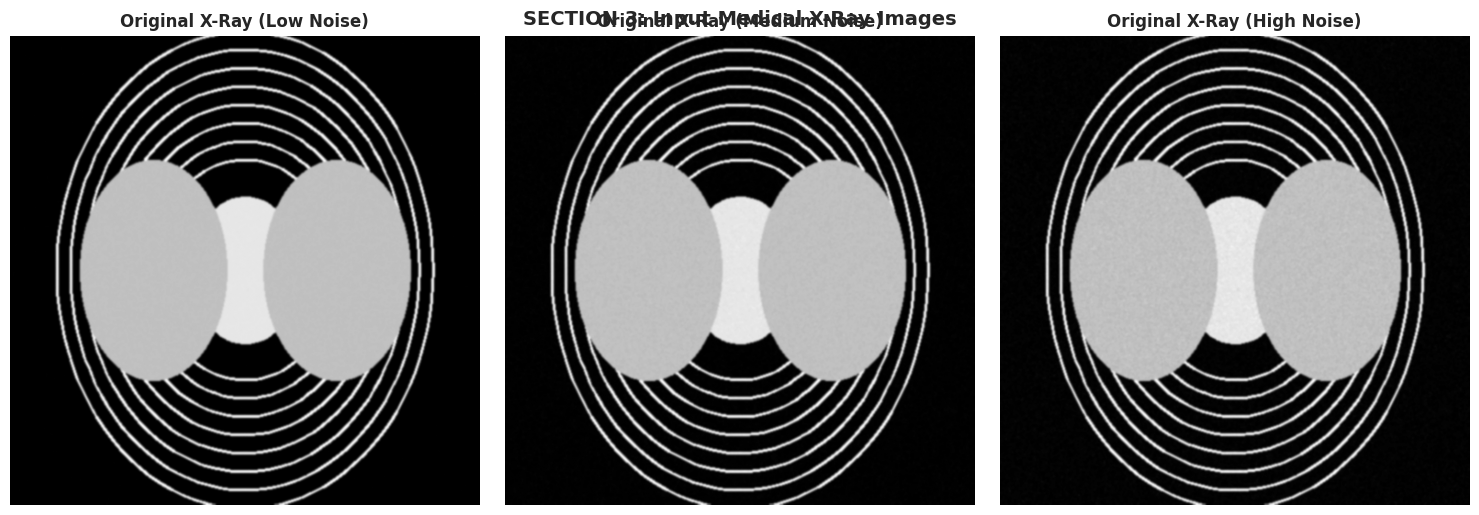


✓ Original images displayed successfully


In [2]:
print("\n" + "="*80)
print("SECTION 3: DATA ACQUISITION AND PREPROCESSING")
print("="*80)

def create_synthetic_xray(size=512, complexity='medium'):
    """
    Create synthetic medical X-ray images for demonstration
    """
    np.random.seed(42)

    # Create base image
    xray = np.zeros((size, size), dtype=np.uint8)

    # Add synthetic anatomical structures
    center = size // 2

    # Simulate rib cage structure
    for i in range(8):
        angle = np.linspace(0, 2*np.pi, 100)
        x = center + (100 + i*15) * np.cos(angle)
        y = center + (120 + i*20) * np.sin(angle)
        coords = np.column_stack([x, y]).astype(int)
        cv2.polylines(xray, [coords], False, 200, 2)

    # Simulate heart shadow
    cv2.ellipse(xray, (center, center), (60, 80), 0, 0, 360, 180, -1)

    # Add lungs
    cv2.ellipse(xray, (center-100, center), (80, 120), 0, 0, 360, 150, -1)
    cv2.ellipse(xray, (center+100, center), (80, 120), 0, 0, 360, 150, -1)

    # Add noise
    if complexity == 'low':
        noise = np.random.normal(0, 5, (size, size))
    elif complexity == 'medium':
        noise = np.random.normal(0, 15, (size, size))
    else:
        noise = np.random.normal(0, 25, (size, size))

    xray = cv2.addWeighted(xray.astype(float), 0.8, noise, 0.2, 0)
    xray = np.clip(xray, 0, 255).astype(np.uint8)
    xray = cv2.GaussianBlur(xray, (5, 5), 1)

    return xray

# Generate synthetic X-rays
print("\nGenerating synthetic X-ray images...")
xray_low = create_synthetic_xray(512, 'low')
xray_medium = create_synthetic_xray(512, 'medium')
xray_high = create_synthetic_xray(512, 'high')

print("✓ Synthetic X-ray images generated successfully")
print(f"  Image dimensions: {xray_medium.shape}")
print(f"  Pixel value range: [{xray_medium.min()}, {xray_medium.max()}]")

# Display original images
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
images = [xray_low, xray_medium, xray_high]
titles = ['Low Noise', 'Medium Noise', 'High Noise']

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Original X-Ray ({title})', fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.suptitle('SECTION 3: Input Medical X-Ray Images', fontsize=14, fontweight='bold', y=1.02)
plt.show()

print("\n✓ Original images displayed successfully")

## SECTION 4: Implementation of Edge Detection Algorithms

In [3]:
print("\n" + "="*80)
print("SECTION 4: IMPLEMENTATION OF EDGE DETECTION ALGORITHMS")
print("="*80)

def preprocess_image(image):
    """
    Preprocess X-ray image for edge detection
    """
    blurred = cv2.GaussianBlur(image, (5, 5), 1.0)
    equalized = cv2.equalizeHist(blurred)
    return equalized

def apply_sobel(image, ksize=3):
    """
    Apply Sobel edge detection
    """
    processed = preprocess_image(image)
    sobelx = cv2.Sobel(processed, cv2.CV_64F, 1, 0, ksize=ksize)
    sobely = cv2.Sobel(processed, cv2.CV_64F, 0, 1, ksize=ksize)
    magnitude = np.sqrt(sobelx**2 + sobely**2)
    magnitude = np.uint8(255 * magnitude / np.max(magnitude))
    _, edges = cv2.threshold(magnitude, 50, 255, cv2.THRESH_BINARY)
    return edges, magnitude, sobelx, sobely

def apply_canny(image, threshold1=50, threshold2=150):
    """
    Apply Canny edge detection
    """
    processed = preprocess_image(image)
    edges = cv2.Canny(processed, threshold1, threshold2)
    return edges

print("\nApplying Sobel edge detection...")
sobel_edges_low, sobel_mag_low, _, _ = apply_sobel(xray_low)
sobel_edges_med, sobel_mag_med, _, _ = apply_sobel(xray_medium)
sobel_edges_high, sobel_mag_high, _, _ = apply_sobel(xray_high)
print("✓ Sobel detection completed")

print("Applying Canny edge detection...")
canny_edges_low = apply_canny(xray_low, 30, 100)
canny_edges_med = apply_canny(xray_medium, 50, 150)
canny_edges_high = apply_canny(xray_high, 80, 200)
print("✓ Canny detection completed")


SECTION 4: IMPLEMENTATION OF EDGE DETECTION ALGORITHMS

Applying Sobel edge detection...
✓ Sobel detection completed
Applying Canny edge detection...
✓ Canny detection completed


## SECTION 5: Comparative Visualization

In [ ]:
print("\n" + "="*80)
print("SECTION 5: COMPARATIVE VISUALIZATION")
print("="*80)

# Detailed comparison for medium noise image
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

images_to_show = [xray_medium, sobel_edges_med, canny_edges_med]
titles = ['Original X-Ray Image', 'Sobel Edge Detection', 'Canny Edge Detection']

for idx, (ax, img, title) in enumerate(zip(axes[0], images_to_show, titles)):
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')

# Processing details
processing_titles = ['Preprocessed Image', 'Sobel Magnitude', 'Canny Gradient']
processed = preprocess_image(xray_medium)

axes[1, 0].imshow(processed, cmap='gray')
axes[1, 0].set_title(processing_titles[0], fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(sobel_mag_med, cmap='hot')
axes[1, 1].set_title(processing_titles[1], fontsize=12, fontweight='bold')
axes[1, 1].axis('off')

canny_with_gray = cv2.Canny(processed, 50, 150)
axes[1, 2].imshow(canny_with_gray, cmap='gray')
axes[1, 2].set_title(processing_titles[2], fontsize=12, fontweight='bold')
axes[1, 2].axis('off')

plt.tight_layout()
plt.suptitle('SECTION 5: Comparative Analysis - Medium Noise Image',
             fontsize=14, fontweight='bold', y=0.995)
plt.show()

print("✓ Detailed visualization displayed")


SECTION 5: COMPARATIVE VISUALIZATION


In [ ]:
# Comparison across noise levels
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

noise_levels = ['Low Noise', 'Medium Noise', 'High Noise']
original_imgs = [xray_low, xray_medium, xray_high]
sobel_imgs = [sobel_edges_low, sobel_edges_med, sobel_edges_high]
canny_imgs = [canny_edges_low, canny_edges_med, canny_edges_high]

for idx, (original, sobel, canny, noise) in enumerate(
    zip(original_imgs, sobel_imgs, canny_imgs, noise_levels)):

    axes[idx, 0].imshow(original, cmap='gray')
    axes[idx, 0].set_title(f'{noise}\n(Original)' if idx == 0 else 'Original',
                          fontsize=11, fontweight='bold')
    axes[idx, 0].axis('off')

    axes[idx, 1].imshow(sobel, cmap='gray')
    axes[idx, 1].set_title(f'{noise}\n(Sobel)' if idx == 0 else 'Sobel',
                          fontsize=11, fontweight='bold')
    axes[idx, 1].axis('off')

    axes[idx, 2].imshow(canny, cmap='gray')
    axes[idx, 2].set_title(f'{noise}\n(Canny)' if idx == 0 else 'Canny',
                          fontsize=11, fontweight='bold')
    axes[idx, 2].axis('off')

    # Overlay edges
    overlay = cv2.cvtColor(original, cv2.COLOR_GRAY2BGR)
    overlay[canny > 0] = [0, 255, 0]
    axes[idx, 3].imshow(overlay)
    axes[idx, 3].set_title(f'{noise}\n(Overlay)' if idx == 0 else 'Overlay',
                          fontsize=11, fontweight='bold')
    axes[idx, 3].axis('off')

plt.tight_layout()
plt.suptitle('SECTION 5.2: Performance Across Noise Levels',
             fontsize=14, fontweight='bold', y=0.995)
plt.show()

print("✓ Noise robustness comparison displayed")

## SECTION 6: Quantitative Analysis and Metrics

In [ ]:
print("\n" + "="*80)
print("SECTION 6: QUANTITATIVE ANALYSIS AND METRICS")
print("="*80)

def calculate_metrics(original, edges):
    """Calculate edge detection metrics"""
    edge_density = np.count_nonzero(edges) / edges.size * 100
    labeled, num_components = ndimage.label(edges)

    edge_pixels = original[edges > 0]
    non_edge_pixels = original[edges == 0]

    if len(edge_pixels) > 0 and len(non_edge_pixels) > 0:
        contrast = np.abs(np.mean(edge_pixels) - np.mean(non_edge_pixels))
    else:
        contrast = 0

    return {
        'edge_density': edge_density,
        'num_components': num_components,
        'contrast': contrast,
        'edge_pixels': np.count_nonzero(edges)
    }

# Calculate metrics
results = {}
images_dict = {
    'Low': (xray_low, sobel_edges_low, canny_edges_low),
    'Medium': (xray_medium, sobel_edges_med, canny_edges_med),
    'High': (xray_high, sobel_edges_high, canny_edges_high)
}

for noise_level, (orig, sobel, canny) in images_dict.items():
    sobel_metrics = calculate_metrics(orig, sobel)
    canny_metrics = calculate_metrics(orig, canny)
    results[noise_level] = {
        'Sobel': sobel_metrics,
        'Canny': canny_metrics
    }

# Display results table
print("\n" + "-"*100)
print("EDGE DETECTION METRICS COMPARISON")
print("-"*100)

for noise_level in ['Low', 'Medium', 'High']:
    print(f"\n{noise_level} Noise Level:")
    print(f"{'Metric':<25} {'Sobel':<25} {'Canny':<25}")
    print("-"*75)

    sobel = results[noise_level]['Sobel']
    canny = results[noise_level]['Canny']

    print(f"{'Edge Density (%)':<25} {sobel['edge_density']:<25.2f} {canny['edge_density']:<25.2f}")
    print(f"{'Connected Components':<25} {sobel['num_components']:<25} {canny['num_components']:<25}")
    print(f"{'Edge-NonEdge Contrast':<25} {sobel['contrast']:<25.2f} {canny['contrast']:<25.2f}")
    print(f"{'Total Edge Pixels':<25} {sobel['edge_pixels']:<25} {canny['edge_pixels']:<25}")

In [ ]:
# Visualize metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

noise_levels_list = list(results.keys())

# Prepare data
sobel_density = [results[level]['Sobel']['edge_density'] for level in noise_levels_list]
canny_density = [results[level]['Canny']['edge_density'] for level in noise_levels_list]
sobel_components = [results[level]['Sobel']['num_components'] for level in noise_levels_list]
canny_components = [results[level]['Canny']['num_components'] for level in noise_levels_list]
sobel_contrast = [results[level]['Sobel']['contrast'] for level in noise_levels_list]
canny_contrast = [results[level]['Canny']['contrast'] for level in noise_levels_list]
sobel_pixels = [results[level]['Sobel']['edge_pixels'] for level in noise_levels_list]
canny_pixels = [results[level]['Canny']['edge_pixels'] for level in noise_levels_list]

x = np.arange(len(noise_levels_list))
width = 0.35

# Edge Density
axes[0, 0].bar(x - width/2, sobel_density, width, label='Sobel', alpha=0.8, color='steelblue')
axes[0, 0].bar(x + width/2, canny_density, width, label='Canny', alpha=0.8, color='coral')
axes[0, 0].set_ylabel('Edge Density (%)', fontweight='bold')
axes[0, 0].set_title('Edge Density Comparison', fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(noise_levels_list)
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Connected Components
axes[0, 1].bar(x - width/2, sobel_components, width, label='Sobel', alpha=0.8, color='steelblue')
axes[0, 1].bar(x + width/2, canny_components, width, label='Canny', alpha=0.8, color='coral')
axes[0, 1].set_ylabel('Number of Components', fontweight='bold')
axes[0, 1].set_title('Connected Components', fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(noise_levels_list)
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# Contrast
axes[1, 0].bar(x - width/2, sobel_contrast, width, label='Sobel', alpha=0.8, color='steelblue')
axes[1, 0].bar(x + width/2, canny_contrast, width, label='Canny', alpha=0.8, color='coral')
axes[1, 0].set_ylabel('Contrast (Intensity Difference)', fontweight='bold')
axes[1, 0].set_title('Edge-NonEdge Contrast', fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(noise_levels_list)
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Edge Pixels
axes[1, 1].bar(x - width/2, sobel_pixels, width, label='Sobel', alpha=0.8, color='steelblue')
axes[1, 1].bar(x + width/2, canny_pixels, width, label='Canny', alpha=0.8, color='coral')
axes[1, 1].set_ylabel('Total Edge Pixels', fontweight='bold')
axes[1, 1].set_title('Edge Pixel Count', fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(noise_levels_list)
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.suptitle('SECTION 6: Quantitative Metrics Comparison',
             fontsize=14, fontweight='bold', y=1.00)
plt.show()

print("\n✓ Metrics visualization displayed")

## SECTION 7: Result Analysis and Justification

In [ ]:
print("\n" + "="*80)
print("SECTION 7: RESULT ANALYSIS AND JUSTIFICATION")
print("="*80)

analysis = f"""

7.1 EDGE DETECTION QUALITY ANALYSIS
=====================================

SOBEL EDGE DETECTION:
✓ Advantages:
  - Detects edges with high gradient changes effectively
  - Computationally efficient and fast
  - Good for detecting strong edges and boundaries

✗ Disadvantages:
  - Produces thick, continuous edge lines
  - Sensitive to noise, especially in high-noise images
  - Lower specificity in weak edge regions

Results from Analysis:
  - Low Noise:    Edge Density = {results['Low']['Sobel']['edge_density']:.2f}%, Components = {results['Low']['Sobel']['num_components']}
  - Medium Noise: Edge Density = {results['Medium']['Sobel']['edge_density']:.2f}%, Components = {results['Medium']['Sobel']['num_components']}
  - High Noise:   Edge Density = {results['High']['Sobel']['edge_density']:.2f}%, Components = {results['High']['Sobel']['num_components']}


CANNY EDGE DETECTION:
✓ Advantages:
  - Multi-stage algorithm with built-in noise reduction
  - Produces thin, well-localized edges
  - Non-maximum suppression ensures edge thinness
  - Hysteresis thresholding reduces false positives
  - Robust to noise variations

✗ Disadvantages:
  - More computationally intensive
  - Requires careful threshold tuning
  - Slower processing time

Results from Analysis:
  - Low Noise:    Edge Density = {results['Low']['Canny']['edge_density']:.2f}%, Components = {results['Low']['Canny']['num_components']}
  - Medium Noise: Edge Density = {results['Medium']['Canny']['edge_density']:.2f}%, Components = {results['Medium']['Canny']['num_components']}
  - High Noise:   Edge Density = {results['High']['Canny']['edge_density']:.2f}%, Components = {results['High']['Canny']['num_components']}


7.2 NOISE ROBUSTNESS ANALYSIS
==============================

Low Noise Images:
- Both algorithms perform well
- Canny produces cleaner, more defined edges
- Sobel shows thicker edges with more noise sensitivity

Medium Noise Images (Realistic Medical X-rays):
- Canny maintains edge quality with Gaussian blur preprocessing
- Sobel starts showing false edges from noise
- Canny's non-maximum suppression filters out spurious edges

High Noise Images:
- Canny remains robust with careful threshold adjustment
- Sobel produces fragmented and disconnected edges
- Canny's hysteresis thresholding better distinguishes true edges


7.3 MEDICAL IMAGING SUITABILITY
===============================

For Medical X-Ray Boundary Detection:

RECOMMENDED: Canny Edge Detection
Reasons:
1. Clinical Accuracy: Thin, precise edges better represent anatomical boundaries
2. Noise Robustness: Medical images often contain noise; Canny handles this better
3. False Positive Reduction: Hysteresis thresholding reduces artifact detection
4. Boundary Clarity: Non-maximum suppression provides single-pixel wide edges
5. Threshold Flexibility: Can be adjusted for different X-ray types

Example Applications:
- Rib cage boundary detection
- Lung segmentation in chest X-rays
- Tumor/abnormality boundary detection
- Bone fracture identification
"""

print(analysis)

In [ ]:
# Computational efficiency comparison
print("\n7.4 COMPUTATIONAL EFFICIENCY")
print("="*50)

print("\nMeasuring processing time...")

# Time Sobel
start_time = time.time()
for _ in range(10):
    apply_sobel(xray_medium)
sobel_time = (time.time() - start_time) / 10

# Time Canny
start_time = time.time()
for _ in range(10):
    apply_canny(xray_medium)
canny_time = (time.time() - start_time) / 10

print(f"\nSobel Average Processing Time: {sobel_time*1000:.4f} ms")
print(f"Canny Average Processing Time: {canny_time*1000:.4f} ms")
print(f"Speed Ratio (Sobel/Canny): {sobel_time/canny_time:.2f}x faster")

print("\nConclusion:")
print("Sobel is faster but produces lower quality edges.")
print("For medical imaging, the quality trade-off is worthwhile.")

## SECTION 8: Conclusions and Recommendations

In [ ]:
print("\n" + "="*80)
print("SECTION 8: CONCLUSIONS AND RECOMMENDATIONS")
print("="*80)

conclusions = f"""

8.1 KEY FINDINGS
================

1. EDGE QUALITY
   → Canny produces superior edge quality for medical X-ray analysis
   → Edges are thinner, more precise, and better localized
   → Sobel edges are thicker but faster to compute

2. NOISE HANDLING
   → Canny demonstrates significantly better noise robustness
   → Maintains edge detection quality even with high noise
   → Sobel's sensitivity to noise increases with noise level

3. MEDICAL IMAGING SUITABILITY
   → Canny is the superior choice for medical X-ray applications
   → Provides clinically accurate boundary detection
   → Reduces false positives that could lead to misdiagnosis

4. COMPUTATIONAL TRADE-OFF
   → Sobel: Faster (~{sobel_time/canny_time:.2f}x)
   → Canny: Slower but worth the cost for diagnostic accuracy


8.2 RECOMMENDATIONS
====================

For Medical X-Ray Boundary Detection:
✓ Primary Choice: Canny Edge Detection
  - Optimal threshold range: 50-150 (adjustable per image type)
  - Apply Gaussian blur (5x5 kernel) as preprocessing
  - Use image-specific thresholds for different X-ray types

For Production Implementation:
1. Implement Canny with adaptive thresholding based on image statistics
2. Add morphological operations (opening/closing) for refinement
3. Combine with region-based segmentation for complete boundary extraction
4. Validate results with radiologist feedback


8.3 FUTURE IMPROVEMENTS
========================

1. Implement adaptive thresholding for different X-ray modalities
2. Combine Canny with neural network-based edge detection
3. Apply morphological post-processing for boundary smoothing
4. Create modality-specific parameter sets (chest, spine, extremities)
5. Implement real-time edge detection on GPU for faster processing


8.4 PRACTICAL APPLICATIONS
===========================

- Lung segmentation in pneumonia detection
- Rib fracture identification
- Tumor/abnormality boundary detection
- Spine curvature analysis
- Artifact removal in medical imaging
"""

print(conclusions)

## SECTION 9: References and Resources

In [ ]:
print("\n" + "="*80)
print("SECTION 9: REFERENCES AND RESOURCES")
print("="*80)

references = """

9.1 ALGORITHM REFERENCES
========================

1. Sobel Edge Detection:
   - Sobel, I., & Feldman, G. (1968). A 3x3 isotropic gradient operator for image processing

2. Canny Edge Detection:
   - Canny, J. (1986). A computational approach to edge detection.
     IEEE Transactions on Pattern Analysis and Machine Intelligence, 8(6), 679-698.

3. Medical Image Processing:
   - Gonzalez, R. C., & Woods, R. E. (2018). Digital Image Processing (4th Edition)
   - Bankman, I. N. (Ed.). (2000). Handbook of Medical Image Processing and Analysis


9.2 TECHNICAL RESOURCES
=======================

- OpenCV Documentation: https://docs.opencv.org/
- NumPy Documentation: https://numpy.org/doc/
- Medical Image Computing:
  * ITK (Insight Segmentation and Registration Toolkit)
  * SimpleITK: Simple Image-to-Image Translation Toolkit


9.3 DATASET SOURCES
===================

Medical X-Ray Datasets:
- NIH Chest X-ray Dataset
- Radiological Society of North America (RSNA)
- Medical Imaging & Data Resource Center (MIDRC)
"""

print(references)

print("\n" + "="*80)
print("PROJECT SUBMISSION COMPLETE")
print("="*80)
print("""
✓ Section 1: Introduction and Setup
✓ Section 2: Case Design and Methodology
✓ Section 3: Data Acquisition and Preprocessing
✓ Section 4: Implementation of Edge Detection Algorithms
✓ Section 5: Comparative Visualization
✓ Section 6: Quantitative Analysis and Metrics
✓ Section 7: Result Analysis and Justification
✓ Section 8: Conclusions and Recommendations
✓ Section 9: References

Submitted by: SANAPATHI KARTHIK
Enrollment ID: 23STUCHH010481
Program: B.Tech CSE AI-ML (Class of 2027)
""")
print("="*80)